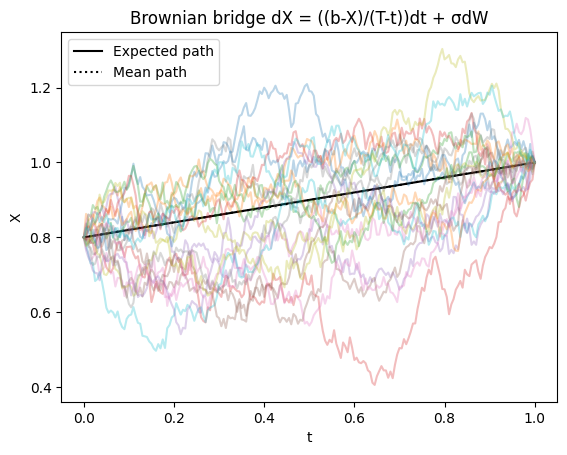

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Monte Carlo simulation of the Brownian bridge
# dX = (b-X)/(T-t)*dt + sigma*dW

# Define parameters and time grid
npaths = 20000  # number of paths
T = 1  # time horizon
nsteps = 200  # number of time steps
dt = T / nsteps  # time step
t = np.linspace(0, T, nsteps + 1)  # observation times
sigma = 0.3  # volatility
a = 0.8  # initial value
b = 1  # final value

# Monte Carlo Method 1

# Allocate and initialize all paths
X = np.zeros((nsteps + 1, npaths))
X[0, :] = a  # Set initial value
X[-1, :] = b  # Set final value

# Compute the Brownian bridge with Euler-Maruyama
for i in range(nsteps - 1):
    X[i + 1, :] = X[i, :] + (b - X[i, :]) / (nsteps - i) + sigma * np.random.randn(npaths) * np.sqrt(dt)

# Monte Carlo Method 2 (Uncomment if needed)
# Compute the increments of driftless arithmetic Brownian motion
# dW = sigma * np.random.randn(nsteps, npaths) * np.sqrt(dt)

# Accumulate the increments of arithmetic Brownian motion
# W = np.vstack([a * np.ones((1, npaths)), np.cumsum(dW, axis=0)])

# Compute the Brownian bridge with X(t) = W(t) + (b-W(T))/T*t
# X = W + (b - W[-1, :]) / T * t[:, None]

# Expected, mean, and sample paths
plt.figure(1)
EX = a + (b - a) / T * t  # expected path
plt.plot(t, EX, 'k', label='Expected path')
plt.plot(t, np.mean(X, axis=1), ':k', label='Mean path')
plt.plot(t, X[:, ::1000], alpha=0.3)  # Plot fewer sample paths for clarity
plt.legend()
plt.xlabel('t')
plt.ylabel('X')

# Optionally adjust y-axis limits based on standard deviation
# sdevmax = sigma * np.sqrt(T) / 2
# plt.ylim([(a + b) / 2 - 4 * sdevmax, (a + b) / 2 + 4 * sdevmax])

plt.title('Brownian bridge dX = ((b-X)/(T-t))dt + σdW')
plt.savefig('bbpaths.png')
plt.show()